# House Price Prediction

## Objective
Predict **house prices** based on key features like area, number of bedrooms, bathrooms, etc.

## Dataset Overview
The dataset includes various features of houses such as:
- Size (sq ft)
- Number of bedrooms and bathrooms
- Location and amenities
- Target variable: `Price`

## Workflow
1. Load and understand the dataset
2. Preprocess the data
3. Train regression models
4. Evaluate predictions

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [2]:
# Load the dataset
df = pd.read_csv("/content/Housing_data.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Size            500 non-null    int64
 1   Bedrooms        500 non-null    int64
 2   Location_Index  500 non-null    int64
 3   Age             500 non-null    int64
 4   Price           500 non-null    int64
dtypes: int64(5)
memory usage: 19.7 KB


,Size,Bedrooms,Location_Index,Age,Price
0,1860,2,2,22,577956
1,2294,1,3,7,754539
2,2130,4,3,14,705595
3,2095,2,5,15,708803
4,2638,4,5,7,908863


## Exploratory Data Analysis (EDA)

In [3]:
# Summary statistics
df.describe()



,Size,Bedrooms,Location_Index,Age,Price
count,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,2522.420000,2.424000,4.982000,25.214000,8.444065e+05
std,845.049606,1.148417,2.594444,13.839337,2.572609e+05
min,1001.000000,1.000000,1.000000,1.000000,3.074720e+05
25%,1815.000000,1.000000,3.000000,13.000000,6.283342e+05
50%,2509.500000,2.000000,5.000000,25.000000,8.509355e+05
75%,3253.500000,3.000000,7.000000,37.000000,1.052989e+06
max,3999.000000,4.000000,9.000000,49.000000,1.348298e+06


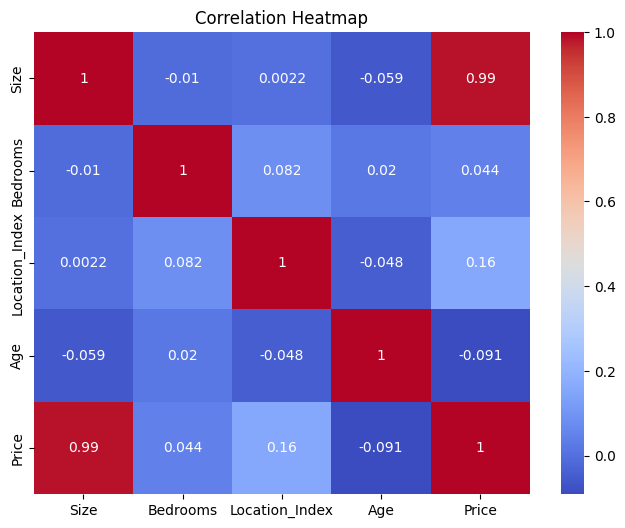

In [4]:
# Visualizing correlation heatmap
plt.figure(figsize=(8,6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()





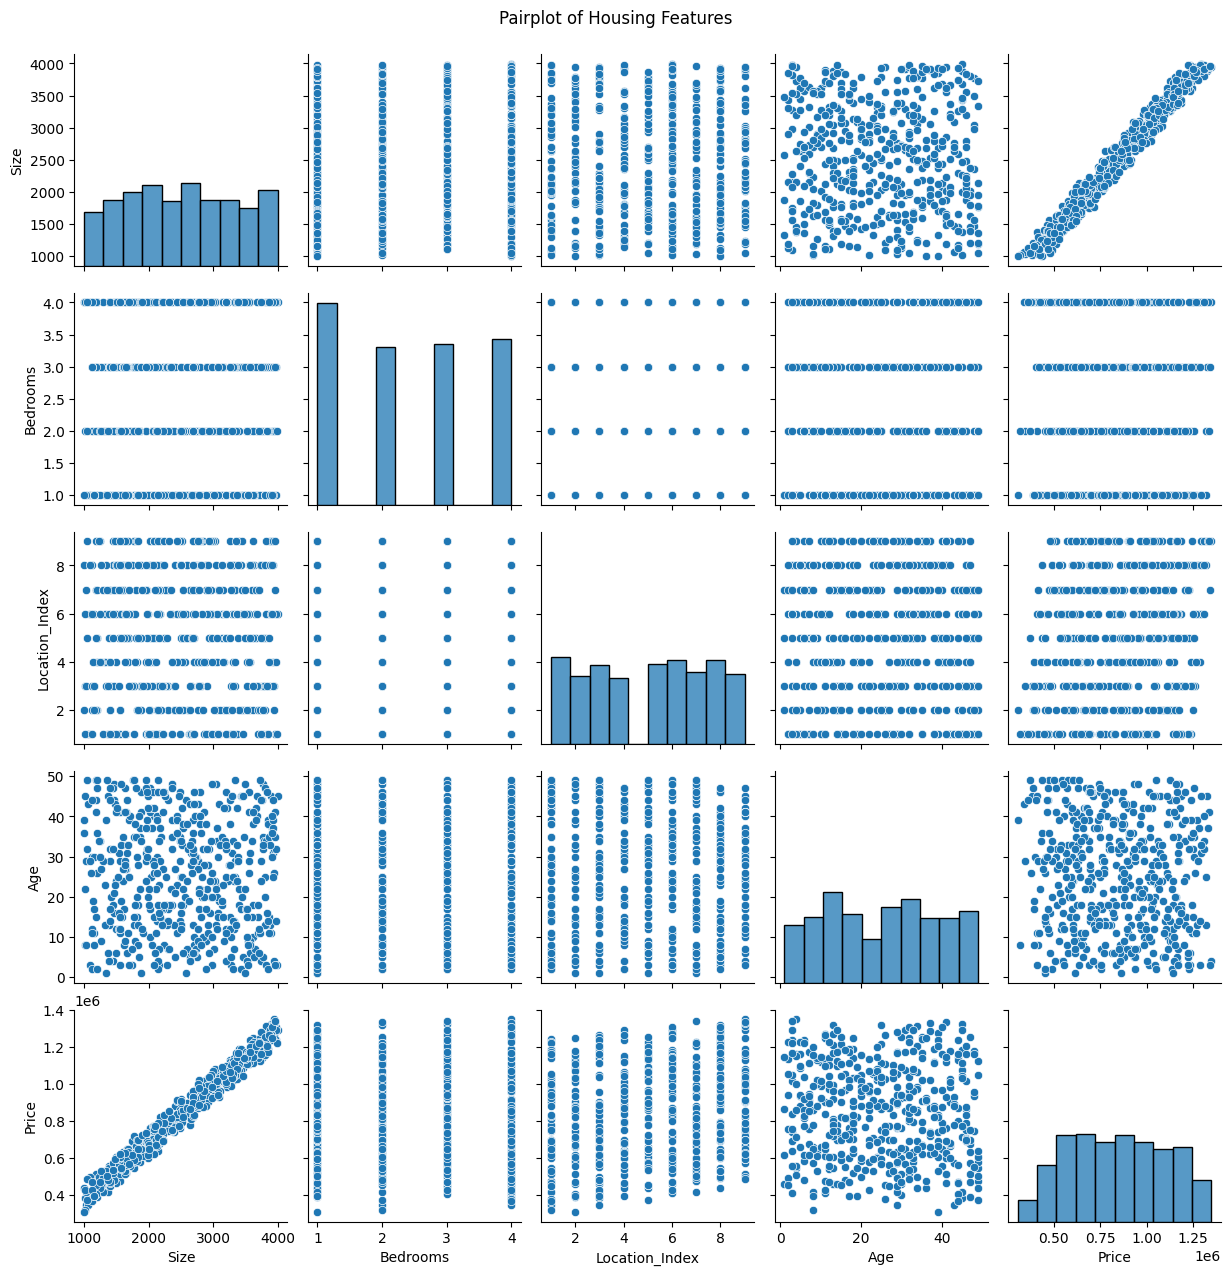

In [5]:
# Pairplot (optional for smaller datasets)
sns.pairplot(df)
plt.suptitle("Pairplot of Housing Features", y=1.02)
plt.show()

## Data Preprocessing




In [6]:
# Check for missing values
df.isnull().sum()



,0
Size,0
Bedrooms,0
Location_Index,0
Age,0
Price,0


In [7]:
# Fill or drop missing values as needed
df.fillna(df.median(), inplace=True)




In [8]:

# Feature and target split
X = df.drop('Price', axis=1)
y = df['Price']


In [9]:

# Optional: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


## Model Training

In [11]:
# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

In [12]:
# Predictions
y_pred = model.predict(X_test)


## Evaluation

In [13]:
# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)



MSE: 147698616.32695642
RMSE: 12153.13195546549
R² Score: 0.9976686364887377


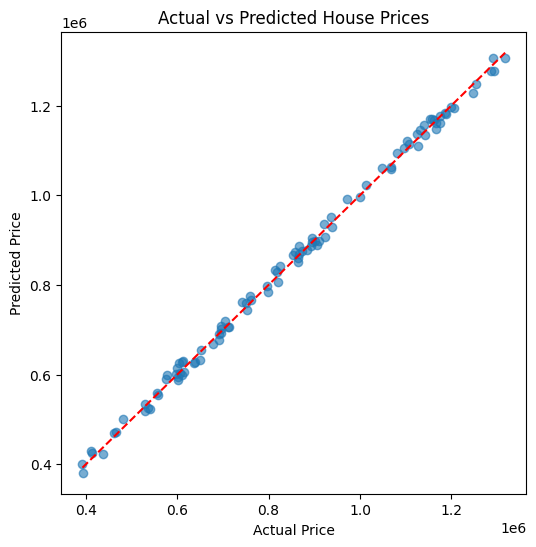

In [14]:
# Plot actual vs predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


## Conclusion
- Linear regression provides a basic prediction model.
- Performance can be improved with feature engineering or using advanced models like Random Forest, XGBoost, or Gradient Boosting.